# A Deep Reinforcement Learning (DQN) Prototype for Energy-Efficient Antenna Sleep Mode Control in O-RAN Cell-Free Massive MIMO Networks

**Energy-Efficient Smart Antenna ON/OFF Control in O-RAN Cell-Free Networks: A Deep Reinforcement Learning Prototype Inspired by EARL**

**Author:** Jay Gautam | **Date:** 22 June 2026 | **Location:** Berlin

---

### Reference and Inspired by the 2026 research paper:

**EARL: Energy-Aware Adaptive Antenna Control with Reinforcement Learning
in O-RAN Cell-Free Massive MIMO Networks**

Zilin Ge, Ozan Alp Topal, Irshad Ahmad Meer, Pei Xiao, and Cicek Cavdar

*Department of Communication Systems, KTH Royal Institute of Technology,
Stockholm, Sweden*

*Institute for Communication Systems (ICS), University of Surrey,
Guildford, United Kingdom*

arXiv:2602.12841v1 [cs.IT] — February 2026

---

Approaches and Impact on Energy Usage: Simple Representation:
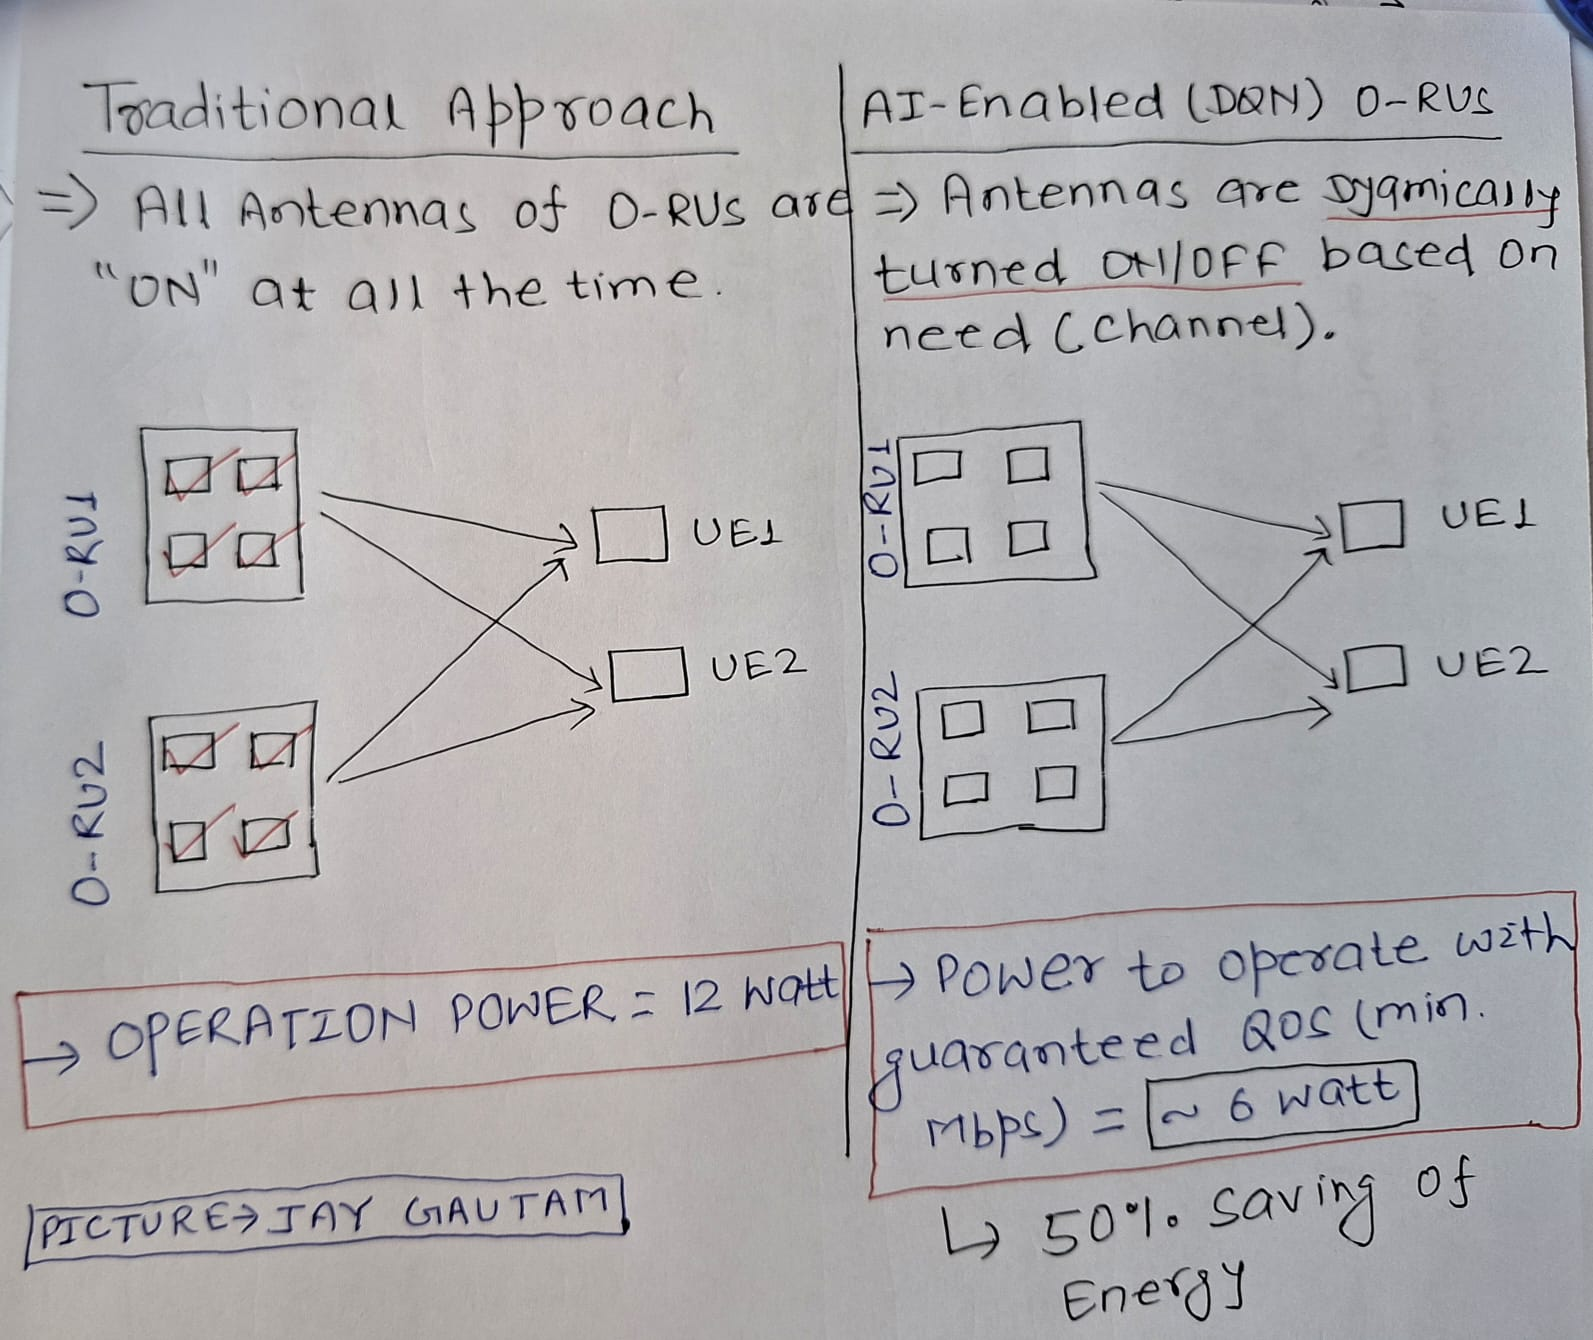

# Setup and Imports
Import all necessary libraries and frameworks. And decided on computing device: CPU or GPU

In [ ]:
# Setup & Imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

SEED = 42 # Reprodicibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Parameters: Wireless and Deep Q Network

In [ ]:
# Dictionary with all the relevant parameters related to wireless and deep learning

CONFIG = {
    # Wireless scenario setup: Problem dimensions
    "L": 2,    # number of O-RUs
    "N": 4,    # max antennas per O-RU
    "K": 2,         # number of UEs
    "SE_min": 1.0,       # minimum required spectral efficiency (bit/s/Hz) for each user

    # Episode structure
    "T": 8,   # max steps per episode (at least 2N)

    # DQN hyperparameters
    "hidden_size": 128,
    "lr": 1e-3, # Learning rate for DQN
    "gamma": 0.99, # Discount factor
    "buffer_size": 10000, #  experience replay buffer of size 10000
    "batch_size": 64, # datas to sample from experience replay buffer
    "target_update_freq": 50,
    "epsilon_start": 1.0, # Epsilon greedy exploration terms
    "epsilon_end": 0.05, # Epsilon greedy exploration terms
    "epsilon_decay_episodes": 300,

    # Training
    "num_episodes": 1500,
}

# To be used in the further codes.
CONFIG["state_dim"] = CONFIG["L"] * CONFIG["K"] + CONFIG["L"] + 2
CONFIG["action_dim"] = 3 ** CONFIG["L"]

print(f"L={CONFIG['L']}, N={CONFIG['N']}, K={CONFIG['K']}")
print(f"State dim = {CONFIG['state_dim']}, Action dim = {CONFIG['action_dim']}")

L=2, N=4, K=2
State dim = 8, Action dim = 9


# Action definition and simulation environment for DQN

In [ ]:
# Action decode and simulation Environment
def decode_action(action_idx, L):
    """
    Actions 0 to 3^L - 1, length-L vector of {-1, 0, +1}.
    -1: turn off one antenna.
    0: no change
    +1: turn on one antenna.
    """
    digits = []
    idx = action_idx
    for _ in range(L):
        digits.append(idx % 3)
        idx //= 3
    return np.array([d - 1 for d in digits], dtype=np.int32)


class CellFreeEnv:
    def __init__(self, config):
        self.L = config["L"]
        self.N = config["N"]
        self.K = config["K"]
        self.SE_min = config["SE_min"]
        self.T = config["T"]

        # simplified power model constants
        self.P_per_antenna = 1.0
        self.P_static_per_RU = 2.0
        self.P_max = self.L * (self.N * self.P_per_antenna + self.P_static_per_RU)

        self.lam = 2.0  # lambda: fixed QoS penalty weight for now — adaptive lambda comes later
        self.reset()
    # Fresh states on every episodes
    def reset(self):
        self.Phi = np.random.uniform(0.05, 1.0, size=(self.L, self.K))  # random channel gains
        # start with all antennas OFF ("close" init) # ones (for all ON) or zeros
        self.n = np.zeros(self.L, dtype=np.int32)
        self.t = 0
        return self._get_state()

    # Spectral efficiency and power computation
    def _compute_SE(self):
        eff_gain = self.n @ self.Phi  # shape (K,) — antennas x channel gain, summed over O-RUs
        return np.log2(1 + eff_gain)

    def _compute_power(self):
        antenna_power = np.sum(self.n) * self.P_per_antenna
        static_power = np.sum(self.n > 0) * self.P_static_per_RU
        return antenna_power + static_power

    def _get_state(self):
        SE = self._compute_SE()
        R_vio = np.mean(SE < self.SE_min) # minimum SE violation: It defines how many users do not have minimum SE value
        P_tot = self._compute_power()
        return np.concatenate([
            self.Phi.flatten(), self.n.astype(np.float32),
            [P_tot / self.P_max], [R_vio]
        ]).astype(np.float32)

    # Agent come with action choice, steps in the environment, takes the reward and move to new state.
    def step(self, action_idx):
        a = decode_action(action_idx, self.L)
        self.n = np.clip(self.n + a, 0, self.N)
        self.t += 1

        SE = self._compute_SE()
        R_vio = np.mean(SE < self.SE_min)
        P_tot = self._compute_power()

        power_term = np.sum(self.n) / (self.L * self.N)
        zeta = 1.0 if np.sum(self.n) == 0 else 0.0
        reward = -power_term - self.lam * R_vio - zeta

        done = self.t >= self.T
        info = {"SE": SE, "P_tot": P_tot, "R_vio": R_vio}
        return self._get_state(), reward, done, info


# Check the function with random values.
env = CellFreeEnv(CONFIG) # object of the environement with parameter dictionary
s = env.reset()
print("Initial state:", s)
print("decode_action(0):", decode_action(0, 2))
print("decode_action(4):", decode_action(4, 2))
print("decode_action(8):", decode_action(8, 2))

s2, r, done, info = env.step(8)  # both O-RUs +1
print("After action 8 (+1,+1):", "reward =", r, info)

Initial state: [0.1982177  0.19819479 0.10517943 0.87286735 0.         0.
 0.         1.        ]
decode_action(0): [-1 -1]
decode_action(4): [0 0]
decode_action(8): [1 1]
After action 8 (+1,+1): reward = -1.25 {'SE': array([0.38227673, 1.05037084]), 'P_tot': np.float64(6.0), 'R_vio': np.float64(0.5)}


# Deep Q Network (DQN) Network: Actor and Target Network

In [ ]:
# Deep Q Network (DQN) Network: Actor and Target Network
# All the variable values imported from CONFIG dictionary
class DQNNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_size):
        super(DQNNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_dim)
        )

    def forward(self, x):
        return self.net(x)


# Online networks, Actor Network
online_net = DQNNetwork(
    CONFIG["state_dim"],
    CONFIG["action_dim"],
    CONFIG["hidden_size"]
).to(device)

# Target networks (Bellmann algorithm), to be used in DQN training
target_net = DQNNetwork(
    CONFIG["state_dim"],
    CONFIG["action_dim"],
    CONFIG["hidden_size"]
).to(device)

# target starts as exact copy of actor model parameters
target_net.load_state_dict(online_net.state_dict())
target_net.eval()  # target never trains independently

# Adam optimizer, used during training
optimizer = optim.Adam(online_net.parameters(), lr=CONFIG["lr"])

# Function check
dummy_state = torch.zeros(1, CONFIG["state_dim"]).to(device)
q_values = online_net(dummy_state)
print("Network output shape:", q_values.shape)   # should be (1, 9)
print("Q-values for zero state:", q_values.detach().cpu().numpy())

Network output shape: torch.Size([1, 9])
Q-values for zero state: [[ 0.06206451  0.02335791 -0.0865905   0.01046468  0.04206008  0.0038518
   0.01989811  0.02665948 -0.13276389]]


# experience replay buffer

In [ ]:
# experience replay buffer: with fixed size memory, max 10000

class ReplayBuffer:
    def __init__(self, buffer_size, batch_size):
        self.buffer = deque(maxlen=buffer_size)
        self.batch_size = batch_size

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    # sample data from buffer to break the temporal correlation between consecutive experiences
    def sample(self):
        batch = random.sample(self.buffer, self.batch_size) # sample data from buffer
        states, actions, rewards, next_states, dones = zip(*batch) # sample data from buffer
        return ( # Torch tensor form for compatibility with NN
            torch.FloatTensor(np.array(states)).to(device),
            torch.LongTensor(np.array(actions)).to(device),
            torch.FloatTensor(np.array(rewards)).to(device),
            torch.FloatTensor(np.array(next_states)).to(device),
            torch.FloatTensor(np.array(dones)).to(device),
        )

    def __len__(self):
        return len(self.buffer)


# Object of Replay Buffer class
buffer = ReplayBuffer(CONFIG["buffer_size"], CONFIG["batch_size"])

# test the buffer class
dummy_s  = np.zeros(CONFIG["state_dim"])
dummy_ns = np.ones(CONFIG["state_dim"])
buffer.push(dummy_s, 4, -0.25, dummy_ns, False)
print("Buffer size after one push:", len(buffer))

s, a, r, ns, d = buffer.sample() if len(buffer) >= CONFIG["batch_size"] else (None,)*5
print("Sample returned None (expected, buffer not full yet):", s is None)
print("Buffer working correctly")

Buffer size after one push: 1
Sample returned None (expected, buffer not full yet): True
Buffer working correctly


# DQN Training Loop

In [ ]:
# DQN Training Loop

def train_dqn(config, env, online_net, target_net, optimizer, buffer):
    episode_rewards = []
    episode_violations = []
    episode_powers = []
    epsilon = config["epsilon_start"]
    epsilon_decay = (config["epsilon_start"] - config["epsilon_end"]) / config["epsilon_decay_episodes"]
    total_steps = 0

    for episode in range(config["num_episodes"]):
        state = env.reset() # generate new states in the start of each episode
        episode_reward = 0
        episode_vio = 0
        episode_power = 0

        for t in range(config["T"]):
            # epsilon greedy action selection
            if random.random() < epsilon:
                action = random.randint(0, config["action_dim"] - 1)  # exploration (random actions)
            else:
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                    q_values = online_net(state_tensor)
                    action = q_values.argmax().item()    # exploitation (familiar actions)

            # environment steps
            next_state, reward, done, info = env.step(action) # step into the environment
            buffer.push(state, action, reward, next_state, float(done)) # store the data
            state = next_state # next state update
            episode_reward += reward
            episode_vio    += info["R_vio"]
            episode_power  += info["P_tot"]
            total_steps    += 1 # step counter

            # training step, only when buffer has enough samples, batch_size= 60
            if len(buffer) >= config["batch_size"]:
                states_b, actions_b, rewards_b, next_states_b, dones_b = buffer.sample()

                # current Q values: online_net value for Q(s,a),
                # ..value for the combination of state and action
                current_q = online_net(states_b).gather(1, actions_b.unsqueeze(1)).squeeze(1)

                # target Q values: Bellman equation, for benchmarkiing
                with torch.no_grad():
                    max_next_q = target_net(next_states_b).max(1)[0]
                    target_q   = rewards_b + config["gamma"] * max_next_q * (1 - dones_b)

                # training for online actor: loss and update
                loss = nn.MSELoss()(current_q, target_q) # MSE loss function
                optimizer.zero_grad() # adam optimizer
                loss.backward()
                optimizer.step()

                # update, sync target network periodically, with model parameters of online_net
                if total_steps % config["target_update_freq"] == 0:
                    target_net.load_state_dict(online_net.state_dict())

        # end of episode, bookkeeping
        epsilon = max(config["epsilon_end"], epsilon - epsilon_decay)
        episode_rewards.append(episode_reward)
        episode_violations.append(episode_vio / config["T"])
        episode_powers.append(episode_power / config["T"])

        # print episode statistics on every 100 episodes
        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            avg_vio    = np.mean(episode_violations[-100:])
            avg_power  = np.mean(episode_powers[-100:])
            print(f"Episode {episode+1:4d} | "
                  f"Avg Reward: {avg_reward:6.3f} | "
                  f"Avg Vio: {avg_vio:.3f} | " # how many users has below threshold SE.
                  f"Avg Power: {avg_power:.2f} | "
                  f"Epsilon: {epsilon:.3f}")

    return episode_rewards, episode_violations, episode_powers


# run training
rewards, violations, powers = train_dqn(
    CONFIG, env, online_net, target_net, optimizer, buffer
)

Episode  100 | Avg Reward: -12.270 | Avg Vio: 0.542 | Avg Power: 4.78 | Epsilon: 0.683
Episode  200 | Avg Reward: -8.150 | Avg Vio: 0.273 | Avg Power: 6.41 | Epsilon: 0.367
Episode  300 | Avg Reward: -6.421 | Avg Vio: 0.166 | Avg Power: 6.81 | Epsilon: 0.050
Episode  400 | Avg Reward: -5.775 | Avg Vio: 0.136 | Avg Power: 6.62 | Epsilon: 0.050
Episode  500 | Avg Reward: -5.429 | Avg Vio: 0.132 | Avg Power: 6.22 | Epsilon: 0.050
Episode  600 | Avg Reward: -5.799 | Avg Vio: 0.138 | Avg Power: 6.63 | Epsilon: 0.050
Episode  700 | Avg Reward: -5.480 | Avg Vio: 0.109 | Avg Power: 6.86 | Epsilon: 0.050
Episode  800 | Avg Reward: -5.671 | Avg Vio: 0.116 | Avg Power: 6.87 | Epsilon: 0.050
Episode  900 | Avg Reward: -5.702 | Avg Vio: 0.131 | Avg Power: 6.62 | Epsilon: 0.050
Episode 1000 | Avg Reward: -5.390 | Avg Vio: 0.119 | Avg Power: 6.41 | Epsilon: 0.050
Episode 1100 | Avg Reward: -5.229 | Avg Vio: 0.114 | Avg Power: 6.24 | Epsilon: 0.050
Episode 1200 | Avg Reward: -5.144 | Avg Vio: 0.113 | 

# Results & Plots
Results & Plots: Reward, Power nd minumum SE Violation

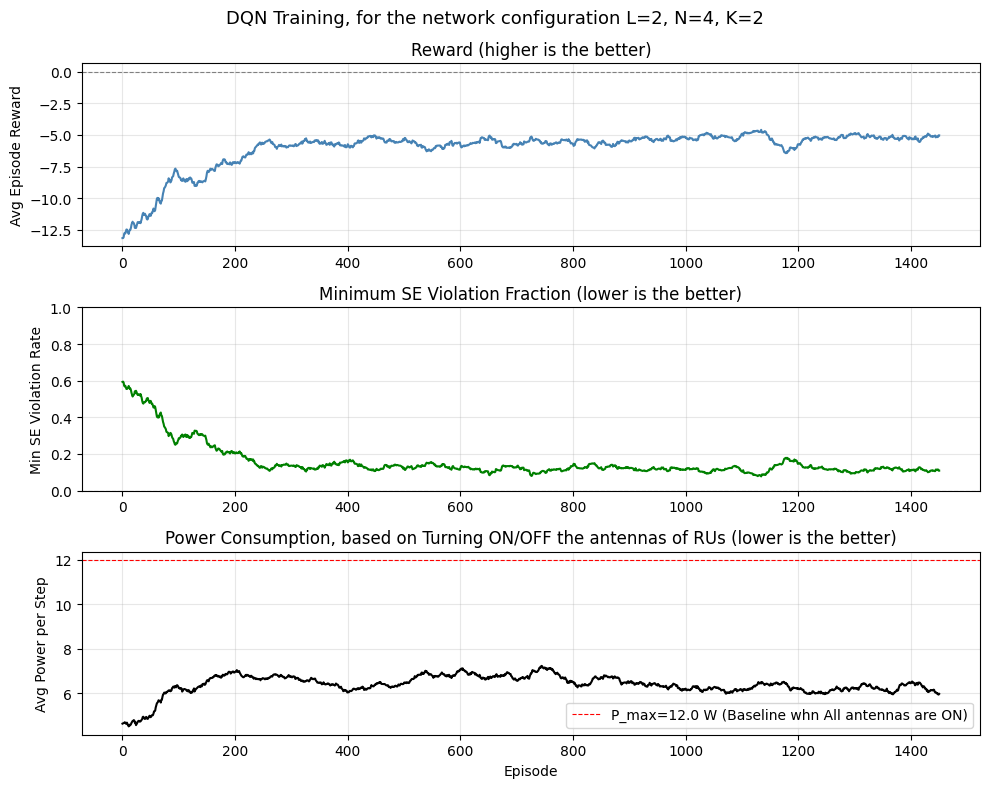

Final 50 episode averages:
  Reward    : -5.035
  Minimum SE Violation : 10.875 %
  Power     : 5.97 / 12.0 (P_max)


In [ ]:
# Results & Plots: Reward, Power nd minumum SE Violation

# Plot function
def plot_training(rewards, violations, powers, window=50):
    fig, axes = plt.subplots(3, 1, figsize=(10, 8))
    fig.suptitle(f"DQN Training, for the network configuration L={CONFIG['L']}, N={CONFIG['N']}, K={CONFIG['K']}", fontsize=13)

    def smooth(data, w):
        return np.convolve(data, np.ones(w)/w, mode='valid')

    episodes = range(len(smooth(rewards, window)))

    # plot 1: reward over the episodes
    axes[0].plot(smooth(rewards, window), color='steelblue')
    axes[0].set_ylabel("Avg Episode Reward")
    axes[0].set_title("Reward (higher is the better)")
    axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    axes[0].grid(True, alpha=0.3)

    # plot 2: violation rate: minumum SE Violation for each users
    axes[1].plot(smooth(violations, window), color='green')
    axes[1].set_ylabel("Min SE Violation Rate")
    axes[1].set_title("Minimum SE Violation Fraction (lower is the better)")
    axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)

    # plot 3: power: power ptimization ver the action.
    # here the agent turns ON/OFF the antennas of the RUs based on optimizazion goal
    axes[2].plot(smooth(powers, window), color='black')
    axes[2].axhline(y=CONFIG["N"] * CONFIG["L"] * 1.0 +
                      CONFIG["L"] * 2.0, color='red',
                      linestyle='--', linewidth=0.8, label='P_max=12.0 W (Baseline whn All antennas are ON)')
    axes[2].set_ylabel("Avg Power per Step")
    axes[2].set_title("Power Consumption, based on Turning ON/OFF the antennas of RUs (lower is the better)")
    axes[2].set_xlabel("Episode")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print("Final 50 episode averages:")
    print(f"  Reward    : {np.mean(rewards[-50:]):.3f}")
    print(f"  Minimum SE Violation : {np.mean(violations[-50:])*100:.3f} %")
    print(f"  Power     : {np.mean(powers[-50:]):.2f} / 12.0 (P_max)")


plot_training(rewards, violations, powers)

**Training Results**
Network Configuration: L=2, N=4, K=2

**Reward (top plot):**
The reward starts at around −12.0 in the early episodes and over the episodes improves to approximately −5.0 by episode 1500. The rising trend confirms that the agent is consistently learning to balance power saving and user satisfaction over time.

**Minumum SE Violation Rate (middle plot):**
The fraction of users falling below the minimum data rate (SE_min = 1.0 bit/s/Hz, 20 Mbps) drops sharply from 60% in the beginning to around 10% by episode 1500. This confirms that the agent correctly learned to prioritize serving users first before trying to save power.

**Power Consumption with ON/OFF antenna pattern (bottom plot):**
The average power per step settles around 6.0 W compared to the full-on baseline of P_max = 12.0 W (red dashed line). This represents approximately 50% power saving compared to keeping all antennas active all the time, while still serving nearly 90% of users above their minimum data rate requirement.

**Final 50-episode averages:** Reward = −5.035, Violation = ~11%, Power = 5.97 / 12.0 W (P_max)